<a href="https://colab.research.google.com/github/Sachitha52/D_ENG_24_0042_a02/blob/main/Imageprocessing2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

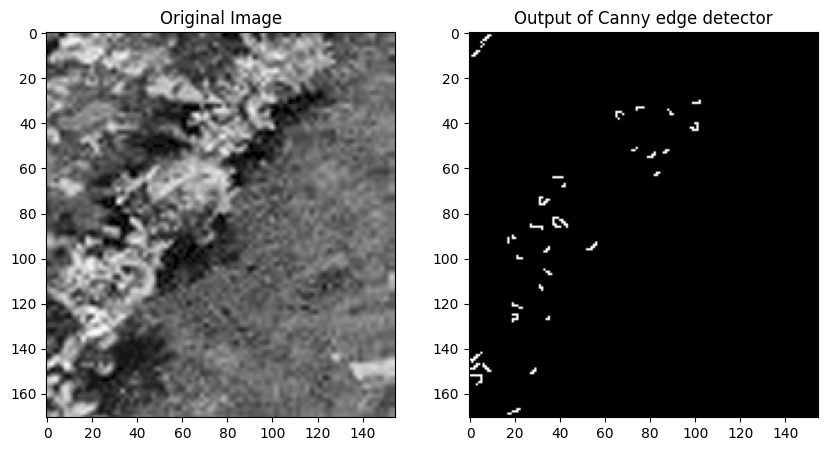

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the cropped image in grayscale
img = cv.imread('cropped segment of the image.png', cv.IMREAD_GRAYSCALE)

# Apply Canny edge detector with the assigned thresholds
edges = cv.Canny(img, 550, 690)

# Plot the original and edge images side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img, cmap='gray')
ax1.set_title('Original Image')
ax2.imshow(edges, cmap='gray')
ax2.set_title('Output of Canny edge detector')
plt.show()

# Extract x and y coordinates of the detected edges
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]

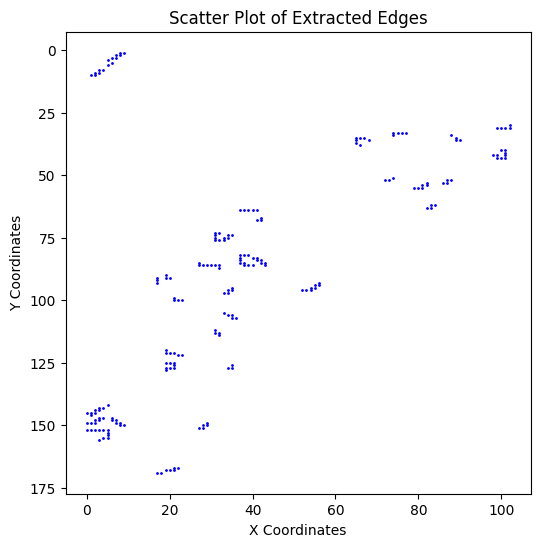

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=1, color='blue')
plt.title('Scatter Plot of Extracted Edges')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')

plt.gca().invert_yaxis()

plt.show()


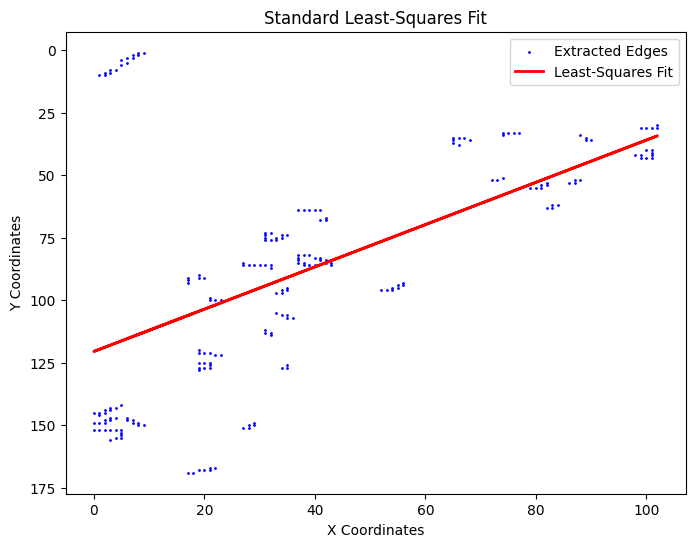

In [12]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# reshape x to be a 2D array, which is required by scikit-learn
x_matrix = x.reshape(-1, 1)

# initialize and fit the linear regression model
ols_model = LinearRegression().fit(x_matrix, y)

# predict the y values based on the fitted model to draw the line
y_pred_ols = ols_model.predict(x_matrix)

# create the scatter plot and overlay the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=1, color='blue', label='Extracted Edges')
plt.plot(x, y_pred_ols, color='red', linewidth=2, label='Least-Squares Fit')
plt.title('Standard Least-Squares Fit')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')

# invert the y-axis to match the image coordinate system
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [13]:
# calculate the slope and base angle
slope_ols = ols_model.coef_[0]
angle_ols_rad = np.arctan(slope_ols)
angle_ols_deg = np.degrees(angle_ols_rad)

# calculate positive representations
positive_magnitude = abs(angle_ols_deg)
positive_geometry = 180 + angle_ols_deg

# print the formatted output
print("--- Answer for Question 04 ---")
print(f"Calculated Slope (m): {slope_ols:.4f}")
print(f"Estimated Crop Field Angle (Original): {angle_ols_deg:.2f} degrees")
print(f"Estimated Crop Field Angle (Absolute Value): {positive_magnitude:.2f} degrees")


--- Answer for Question 04 ---
Calculated Slope (m): -0.8457
Estimated Crop Field Angle (Original): -40.22 degrees
Estimated Crop Field Angle (Absolute Value): 40.22 degrees


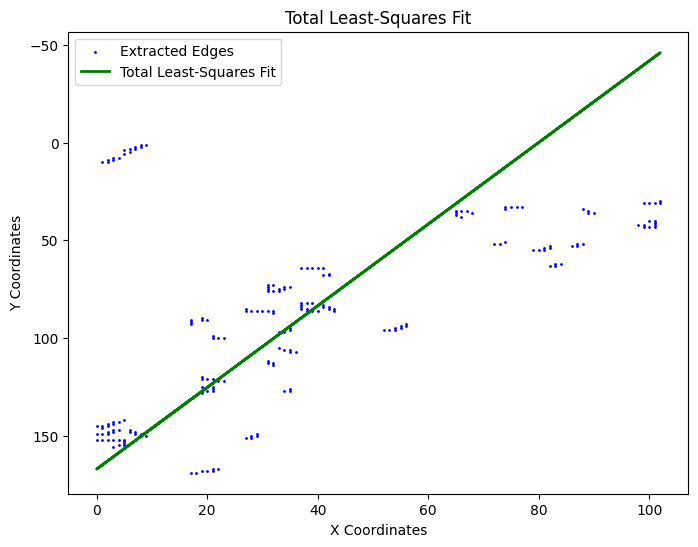

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import Model, Data, ODR

# define the linear mathematical function for the model
def linear_func(p, x_val):
    return p[0] * x_val + p[1]

# set up the model and the data structure required by scipy.odr
linear_model = Model(linear_func)
data = Data(x, y)

# initialize the algorithm with some basic initial guesses for slope and intercept
odr_model = ODR(data, linear_model, beta0=[-1.0, 100.0])

# run the optimization to find the best fit
odr_output = odr_model.run()

# extract the calculated slope and intercept from the output
slope_tls = odr_output.beta[0]
intercept_tls = odr_output.beta[1]

# calculate the corresponding y values to draw the fitted line
y_pred_tls = slope_tls * x + intercept_tls

# create the scatter plot and overlay the total least-squares line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=1, color='blue', label='Extracted Edges')
plt.plot(x, y_pred_tls, color='green', linewidth=2, label='Total Least-Squares Fit')
plt.title('Total Least-Squares Fit')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')

# invert the y-axis to match the image orientation
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [15]:
import numpy as np

# calculate the angle in radians and convert to degrees
angle_tls_rad = np.arctan(slope_tls)
angle_tls_deg = np.degrees(angle_tls_rad)

# calculate the positive magnitude for clarity
positive_magnitude_tls = abs(angle_tls_deg)

# print the formatted output
print("--- Answer for Question 07 ---")
print(f"Calculated TLS Slope (m): {slope_tls:.4f}")
print(f"Estimated Crop Field Angle (Original): {angle_tls_deg:.2f} degrees")
print(f"Estimated Crop Field Angle (Absolute Value): {positive_magnitude_tls:.2f} degrees")

--- Answer for Question 07 ---
Calculated TLS Slope (m): -2.0904
Estimated Crop Field Angle (Original): -64.43 degrees
Estimated Crop Field Angle (Absolute Value): 64.43 degrees


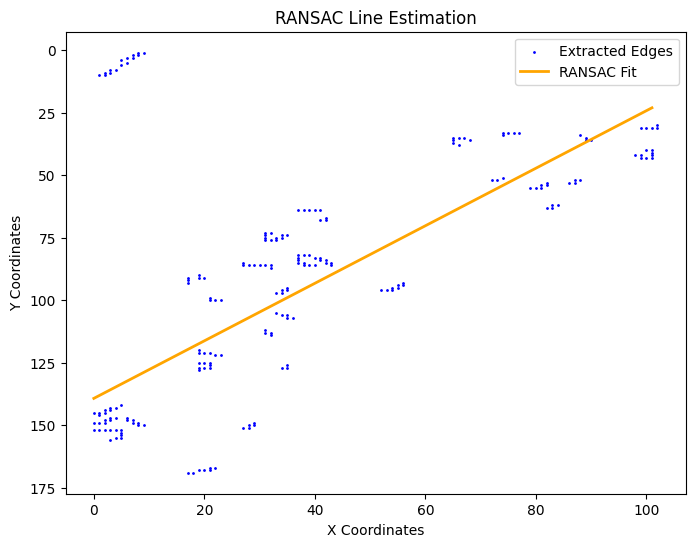

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

x_matrix = x.reshape(-1, 1)

ransac = RANSACRegressor()
ransac.fit(x_matrix, y)

line_x = np.arange(x.min(), x.max())[:, np.newaxis]
line_y_ransac = ransac.predict(line_x)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', s=1, label='Extracted Edges')
plt.plot(line_x, line_y_ransac, color='orange', linewidth=2, label='RANSAC Fit')
plt.title('RANSAC Line Estimation')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [21]:
import numpy as np

# extract the slope from the core linear estimator inside RANSAC
slope_ransac = ransac.estimator_.coef_[0]

# calculate the angle in radians and convert to degrees
angle_ransac_rad = np.arctan(slope_ransac)
angle_ransac_deg = np.degrees(angle_ransac_rad)

# calculate the positive magnitude for clarity
positive_magnitude_ransac = abs(angle_ransac_deg)

# print the formatted output
print("--- Answer for Question 11 ---")
print(f"Calculated RANSAC Slope (m): {slope_ransac:.4f}")
print(f"Estimated Crop Field Angle (Original): {angle_ransac_deg:.2f} degrees")
print(f"Estimated Crop Field Angle (Absolute Value): {positive_magnitude_ransac:.2f} degrees")

--- Answer for Question 11 ---
Calculated RANSAC Slope (m): -1.1508
Estimated Crop Field Angle (Original): -49.01 degrees
Estimated Crop Field Angle (Absolute Value): 49.01 degrees
